# GT Matching 시각화
combination.csv의 페어에 대해 GT correspondence를 라인으로 시각화합니다.

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("gluefactory/datasets/mitsubishi")
COMBO = pd.read_csv(BASE_DIR / "outputs_txt" / "combination.csv")
print(f"Total pairs: {len(COMBO)}")
COMBO.head()

Total pairs: 64000


,master_path,input_path,csv_path
0,dataset_resample_2/depth_raw_0000.png,dataset_resample_2/depth_raw_0001.png,outputs_txt/00000.csv
1,dataset_resample_2/depth_raw_0000.png,dataset_resample_2/depth_raw_0002.png,outputs_txt/00001.csv
2,dataset_resample_2/depth_raw_0000.png,dataset_resample_2/depth_raw_0003.png,outputs_txt/00002.csv
3,dataset_resample_2/depth_raw_0000.png,dataset_resample_2/depth_raw_0004.png,outputs_txt/00003.csv
4,dataset_resample_2/depth_raw_0000.png,dataset_resample_2/depth_raw_0005.png,outputs_txt/00004.csv


In [13]:
def show_gt_matches(pair_idx, max_lines=100, image_size=None, show_occluded=True):
    """
    GT correspondence를 시각화.
    
    Args:
        pair_idx: combination.csv에서의 인덱스
        max_lines: 그릴 최대 매칭 선 수
        image_size: 리사이즈할 크기 (None이면 원본)
        show_occluded: True면 occluded 포인트도 표시
    """
    row = COMBO.iloc[pair_idx]
    
    # 이미지 로드
    master_raw = cv2.imread(str(BASE_DIR / row["master_path"]), cv2.IMREAD_UNCHANGED)
    input_raw = cv2.imread(str(BASE_DIR / row["input_path"]), cv2.IMREAD_UNCHANGED)
    orig_h, orig_w = master_raw.shape[:2]
    
    # 리사이즈
    if image_size is not None and image_size != orig_h:
        master_disp = cv2.resize(master_raw, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
        input_disp = cv2.resize(input_raw, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
        scale = image_size / orig_w
    else:
        master_disp = master_raw
        input_disp = input_raw
        scale = 1.0
        image_size = orig_h
    
    # 정규화 (시각화용)
    master_vis = master_disp.astype(np.float32) / 65535.0
    input_vis = input_disp.astype(np.float32) / 65535.0
    
    # GT 로드
    csv_path = BASE_DIR / "outputs" / Path(row["csv_path"]).name
    corr = pd.read_csv(csv_path)
    
    master_xy = corr[["master_x", "master_y"]].values.astype(np.float32) * scale
    input_xy = corr[["input_x", "input_y"]].values.astype(np.float32) * scale
    occluded = corr["occluded"].values.astype(bool)
    
    n_total = len(corr)
    n_visible = int((~occluded).sum())
    n_occluded = int(occluded.sum())
    
    # 그리기
    fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=100)
    
    axes[0].imshow(master_vis, cmap="gray")
    axes[0].set_title(f"Master: {Path(row['master_path']).name}", fontsize=12)
    axes[0].set_axis_off()
    
    axes[1].imshow(input_vis, cmap="gray")
    axes[1].set_title(f"Input: {Path(row['input_path']).name}", fontsize=12)
    axes[1].set_axis_off()
    
    # 매칭 선
    if show_occluded:
        indices = np.arange(n_total)
    else:
        indices = np.where(~occluded)[0]
    
    # 너무 많으면 랜덤 샘플
    if len(indices) > max_lines:
        indices = np.random.choice(indices, max_lines, replace=False)
    
    for i in indices:
        color = "limegreen" if occluded[i] else "skyblue"
        alpha = 0.4 if occluded[i] else 0.7
        lw = 0.5 if occluded[i] else 0.8
        
        line = matplotlib.patches.ConnectionPatch(
            xyA=(float(master_xy[i, 0]), float(master_xy[i, 1])),
            xyB=(float(input_xy[i, 0]), float(input_xy[i, 1])),
            coordsA=axes[0].transData,
            coordsB=axes[1].transData,
            axesA=axes[0],
            axesB=axes[1],
            color=color,
            linewidth=lw,
            alpha=alpha,
        )
        fig.add_artist(line)
    
    # 키포인트 표시
    vis_mask = ~occluded if not show_occluded else np.ones(n_total, dtype=bool)
    axes[0].scatter(master_xy[~occluded, 0], master_xy[~occluded, 1],
                    c="skyblue", s=20, alpha=0.5, linewidths=0, label=f"visible ({n_visible})")
    axes[1].scatter(input_xy[~occluded, 0], input_xy[~occluded, 1],
                    c="skyblue", s=20, alpha=0.5, linewidths=0)
    if show_occluded and n_occluded > 0:
        axes[0].scatter(master_xy[occluded, 0], master_xy[occluded, 1],
                        c="limegreen", s=20, alpha=0.3, linewidths=0, label=f"occluded ({n_occluded})")
        axes[1].scatter(input_xy[occluded, 0], input_xy[occluded, 1],
                        c="limegreen", s=20, alpha=0.3, linewidths=0)
    
    axes[0].legend(fontsize=9, loc="upper right")
    
    fig.suptitle(
        f"Pair #{pair_idx}  |  GT: {n_total} total  |  "
        f"visible(skyblue): {n_visible}  |  occluded(green): {n_occluded}  |  "
        f"showing {len(indices)} lines",
        fontsize=10, y=0.02,
    )
    fig.tight_layout()
    plt.show()
    
    return corr

## 사용법
- `pair_idx`: combination.csv 인덱스 (0 ~ len-1)
- `max_lines`: 그릴 매칭 선 최대 수 (너무 많으면 느림)
- `image_size`: 리사이즈 (None=원본 5761, 2880 추천)
- `show_occluded`: occluded 포인트도 표시할지

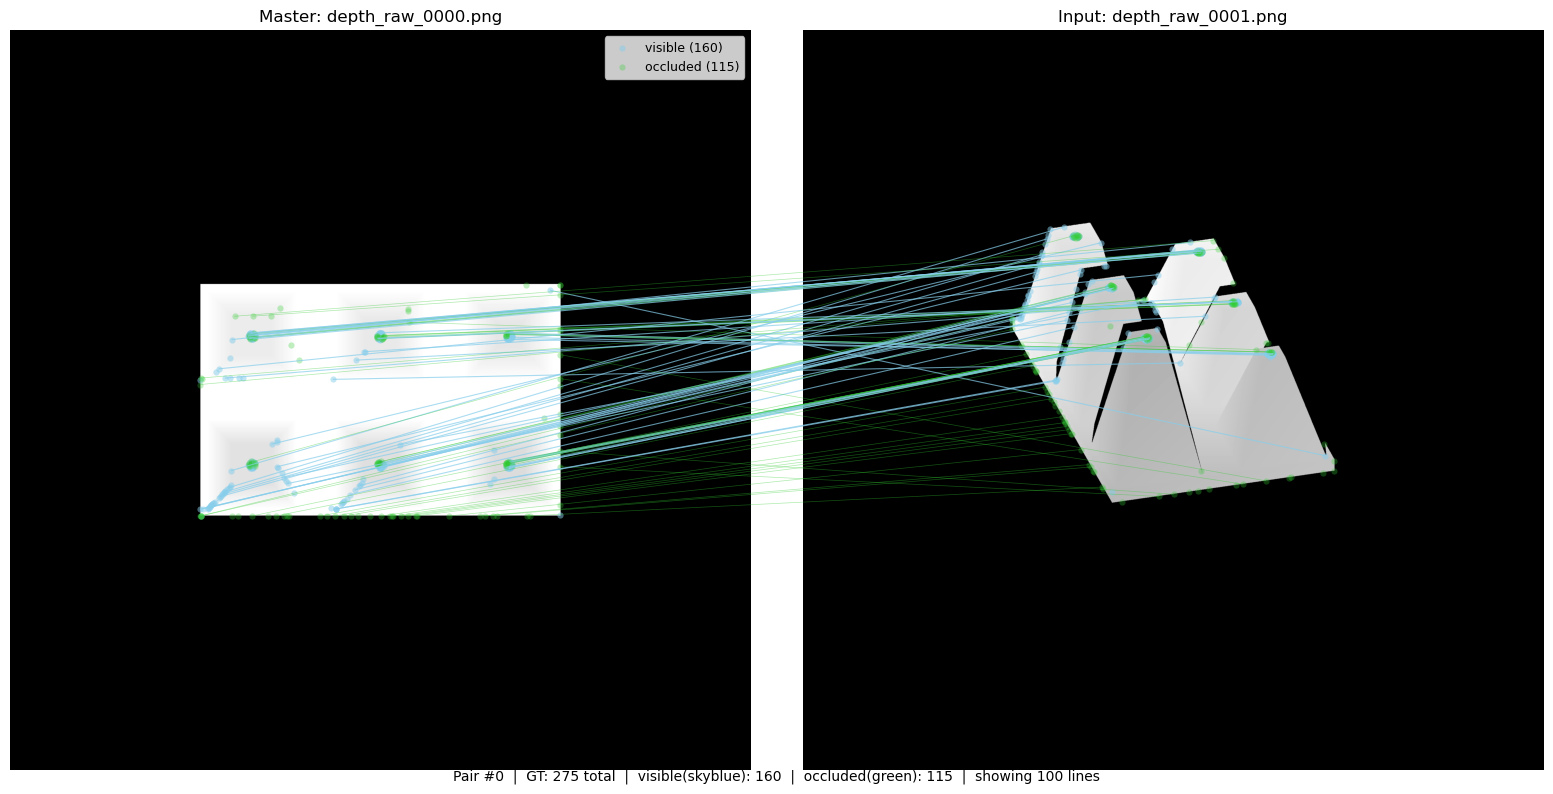

In [14]:
# 첫 번째 페어 시각화 (2880 리사이즈, 매칭 선 100개)
corr = show_gt_matches(pair_idx=0, max_lines=100, image_size=2880)

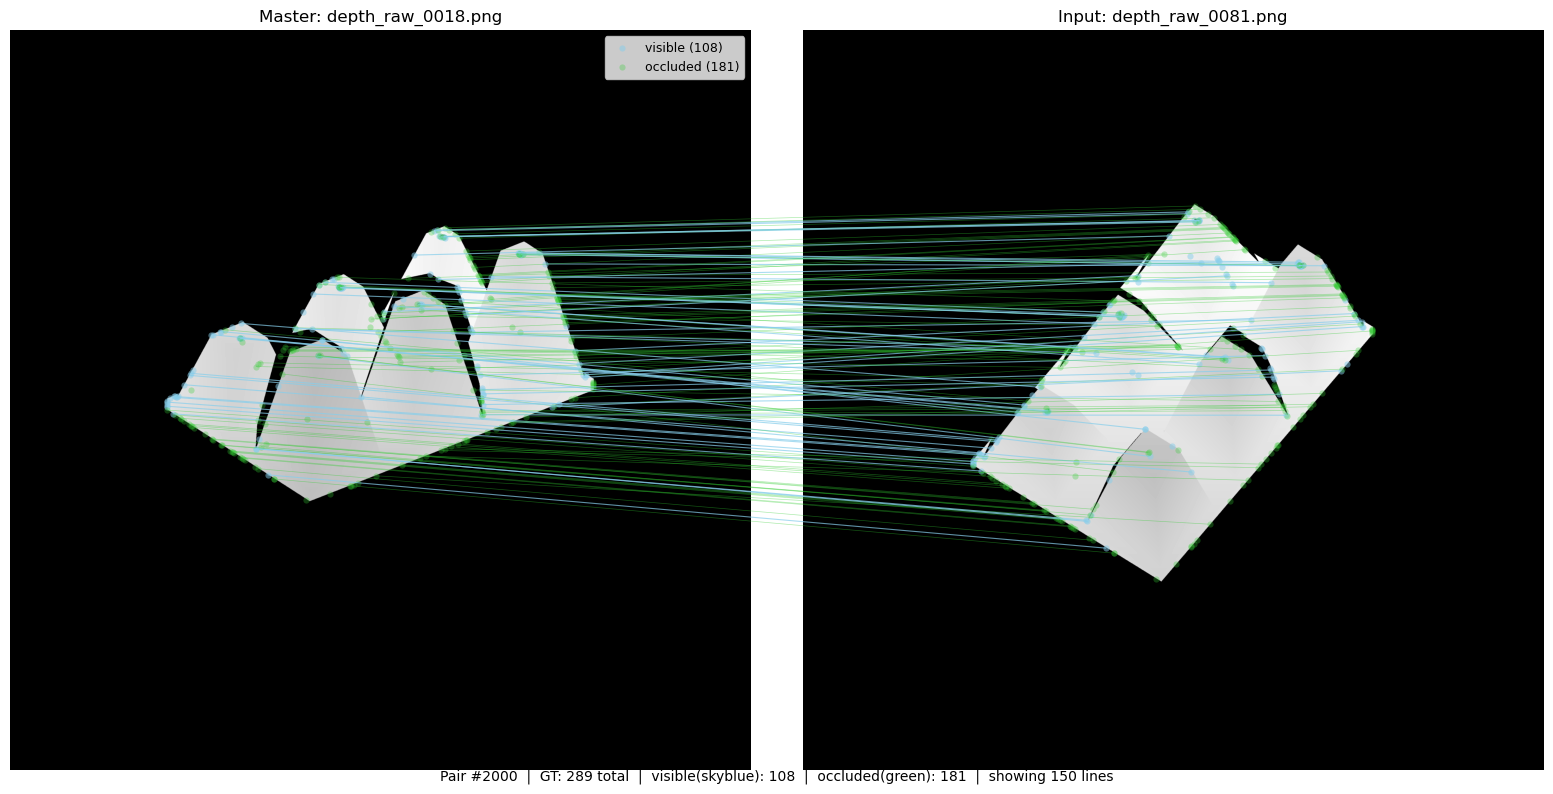

In [15]:
# 다른 페어 보기
corr = show_gt_matches(pair_idx=2000, max_lines=150, image_size=2880)

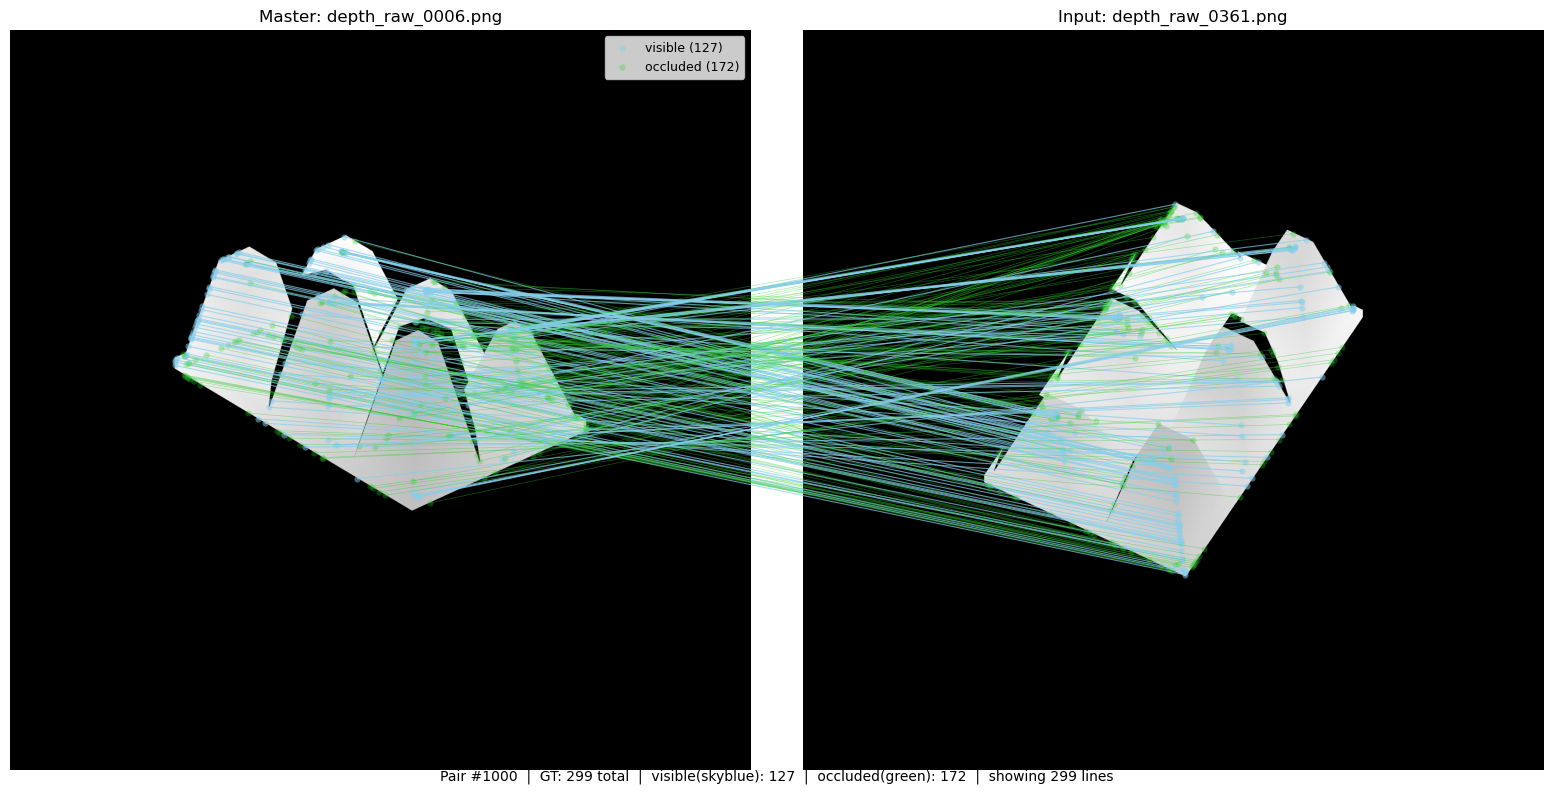

In [16]:
# occluded 제외하고 보기
corr = show_gt_matches(pair_idx=1000, max_lines=300, image_size=2880)

Train: 0 ~ 63799
Val:   63800 ~ 63899
Test:  63900 ~ 63999


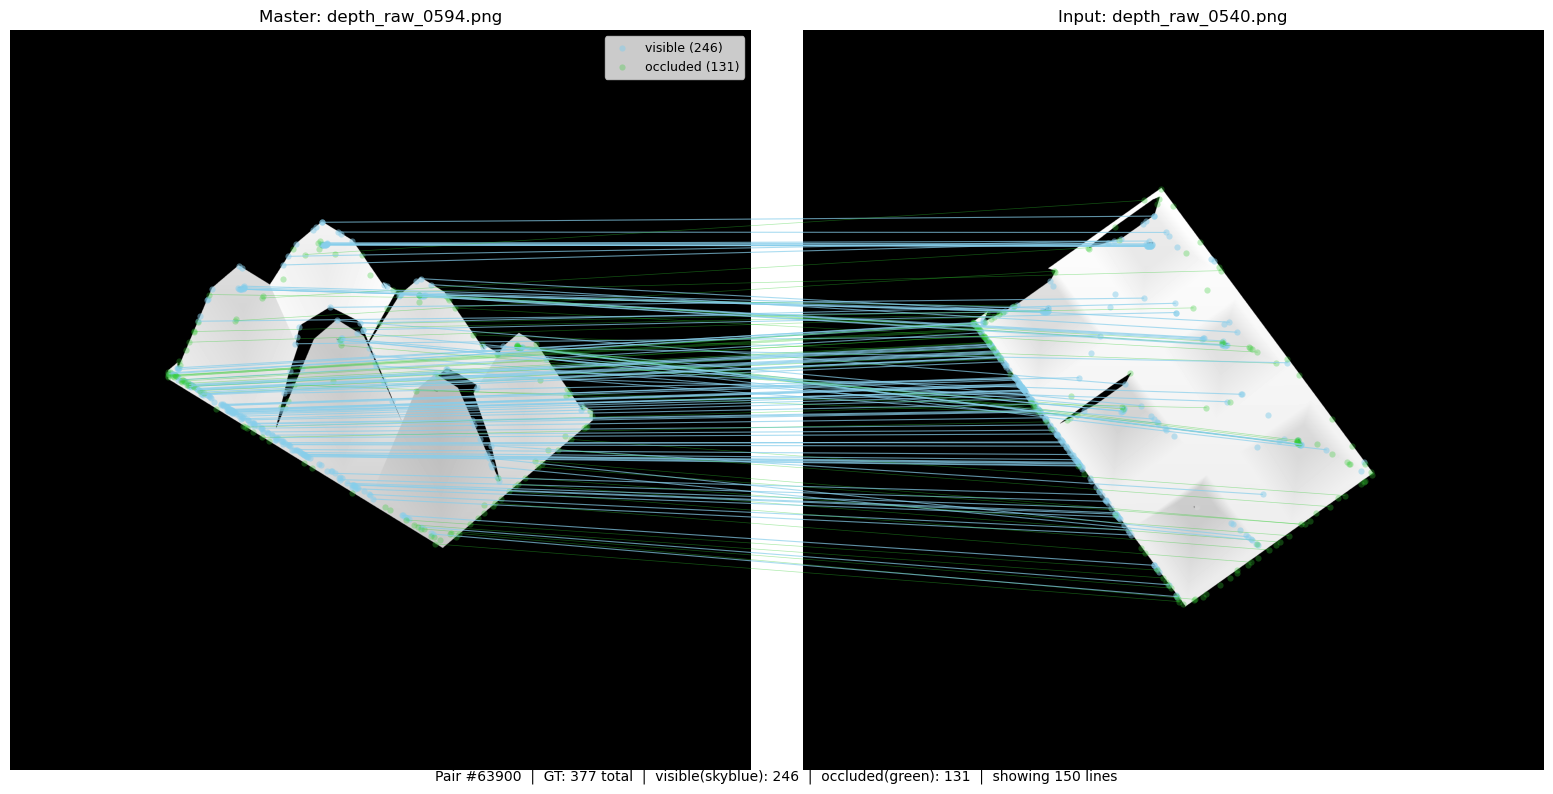

In [17]:
# test split 시작 인덱스 확인
total = len(COMBO)
print(f"Train: 0 ~ {total-201}")
print(f"Val:   {total-200} ~ {total-101}")
print(f"Test:  {total-100} ~ {total-1}")

# test split 첫 번째 페어
corr = show_gt_matches(pair_idx=total-100, max_lines=150, image_size=2880)

In [3]:
  import pyshot                                                                                                                                               
  import numpy as np                                                                                                                                          
                                                                                                                                                              
#   vertices = np.array(...)  # shape (n, 3) — 3D 점들                                                                                                          
#   faces = np.array(...)     # shape (m, 3) — 삼각형 메쉬 face indices                                                                                         
                                                                                                                                                              
#   shot_descrs = pyshot.get_descriptors(                                                                                                                       
#       vertices,                                                                                                                                               
#       faces,                                                                                                                                                  
#       radius=100,                                                                                                                                             
#       local_rf_radius=100,                                                                                                                                    
#       min_neighbors=3,                                                                                                                                        
#       n_bins=20,                                                                                                                                              
#   )                                                                                                                                                           
#   # shot_descrs.shape == (n, 352)  — 기본 SHOT descriptor 차원